## Prepare dataset

In [1]:
import os
from pathlib import Path

In [2]:
TOPCOW_PATH = '/data/falcetta/NNUNET25/nnUNet_raw'

for dataset in os.listdir(TOPCOW_PATH):
    print(f'{dataset}')


Dataset303_CTCOW24
Dataset304_MRCOW24
Dataset301_CTCOW23
Dataset302_MRCOW23


In [3]:
DATASET = 'Dataset301_CTCOW23'# Dataset303_CTCOW24, Dataset304_MRCOW24, Dataset301_CTCOW23, Dataset302_MRCOW23
dataset = DATASET
JUST_TEST = True # If True, all the data will be used for testing

In [4]:
YEAR = DATASET[-2:]
MOD = DATASET.split('_')[-1][:2]

assert YEAR in ['23', '24']
assert MOD in ['CT', 'MR']

DATASET_NAME = "TOPCOW_" + YEAR + MOD
if JUST_TEST:
    DATASET_NAME += "_TEST"

print(f"DATASET_NAME: {DATASET_NAME}")
OUT_DIR = f'/data/falcetta/TOPCOW_RES/A2V/{YEAR}/{MOD}/'
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

print(f"OUT_DIR: {OUT_DIR}")

DATASET_NAME: TOPCOW_23CT_TEST
OUT_DIR: /data/falcetta/TOPCOW_RES/A2V/23/CT/


In [5]:
DATA_PATH = os.path.join(TOPCOW_PATH, DATASET, 'imagesTs')
complete_flag = True


#these functions are to define for each new dataset, unless fixing a rule
#they allow to define a clear association between the data path of a brain image and the corresponding brain/vessel mask
#the brain mask is not mandatory, if not present just return None
import utils
def img_path_to_brain_path(img_path):
    return img_path.replace("imagesT", "brainT").replace(".nii.gz", "_brain_join_mask.nii.gz")
def img_path_to_vessel_path(img_path):
    return img_path.replace("imagesT", "labelsT")
def img_path_to_weight_path(img_path):
    return "ERROR"

# IF WE WANT TO DO EXPERIMENTS WITH COMPLETE VESSEL MASKS
def img_path_to_vessel_path_complete(img_path):
    vessel_path = img_path.replace("imagesT", "labelsT").replace(".nii.gz", "_COMPLETE_new.nii.gz")
    return vessel_path
def img_path_to_weight_path_complete(img_path):
    return "ERROR"

utils.img_path_to_brain_path = img_path_to_brain_path
if complete_flag:
    utils.img_path_to_weight_path = img_path_to_weight_path_complete
    utils.img_path_to_vessel_path = img_path_to_vessel_path_complete
else:
    utils.img_path_to_weight_path = img_path_to_weight_path 
    utils.img_path_to_vessel_path = img_path_to_vessel_path 

#this regex works as a filter in case you have unnecessary .nii files in your dataset folder
PATH_RULE = r"^(?:.*/)?topcow_mr_whole_[0-9]{3}\.nii\.gz$" if MOD == 'MR' else r"^(?:.*/)?topcow_ct_whole_[0-9]{3}\.nii\.gz$"

if YEAR == '24':
    PATH_RULE = r"^(?:.*/)?topcow_mr_[0-9]{3}\.nii\.gz$" if MOD == 'MR' else r"^(?:.*/)?topcow_ct_[0-9]{3}\.nii\.gz$"

#if you have some outliers you want to discard, you can specify it in the list below
OUTLIERs = []

#if you need to preprocess also images with no vessel masks set the following flag to False
VESSELs_REQUIRED = False

#this parameter is to unify the orientation of our images
#set it True if you notice in the examples shown below that the nose is oriented downward and not upward
utils.do_flip = False

### Extract paths

In [6]:
import os

from utils import search_nii, extract_paths, load_info_from_checkpoint

In [7]:
if not os.path.isfile(f"info_{DATASET_NAME}.pkl"):
    info = {
        "train": extract_paths(path_rule=PATH_RULE),
        "val": None,
        "test": None,
    }
    search_nii(DATA_PATH, info["train"])
else:
    info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [9]:
for selected_pth in info["train"].paths:
    print(selected_pth)
for selected_pth in info["test"].paths:
    print(selected_pth)

/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/imagesTs/topcow_ct_whole_001.nii.gz
/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/imagesTs/topcow_ct_whole_002.nii.gz
/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/imagesTs/topcow_ct_whole_003.nii.gz
/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/imagesTs/topcow_ct_whole_004.nii.gz
/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/imagesTs/topcow_ct_whole_005.nii.gz
/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/imagesTs/topcow_ct_whole_006.nii.gz
/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/imagesTs/topcow_ct_whole_007.nii.gz
/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/imagesTs/topcow_ct_whole_008.nii.gz
/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/imagesTs/topcow_ct_whole_009.nii.gz
/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/imagesTs/topcow_ct_whole_010.nii.gz
/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/imagesTs/topcow_ct_whole_011.nii.gz
/data/falc

### Display examples

In [9]:
import random

from utils import print_bold, load_and_display_middle_slice

[Example 01]
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 307 384 214   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [1.         0.4453125  0.4453125  0.70000076 1.         1.
 1.         1.        ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'Time=205850.645'
aux_file        : b''
qform_code      : unknown
sform_code      : aligned
quatern_b       : 0.0
quatern_c       : 0.0
quatern_d       : 1.0
qoffset_x       : 73.91797
qoffset_y

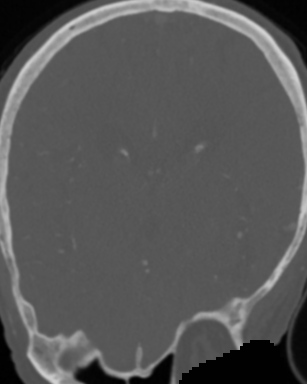

[Example 02]
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 286 379 202   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [1.         0.48242188 0.48242188 0.75       1.         1.
 1.         1.        ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'Time=183308.910'
aux_file        : b''
qform_code      : unknown
sform_code      : aligned
quatern_b       : 0.0
quatern_c       : 0.0
quatern_d       : 1.0
qoffset_x       : 66.33301
qoffset_y

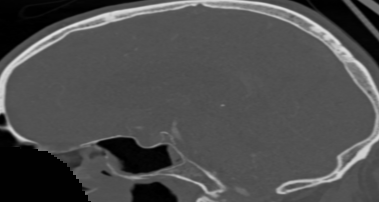

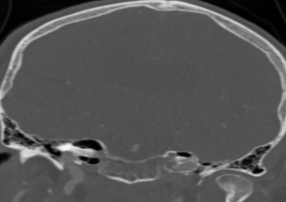

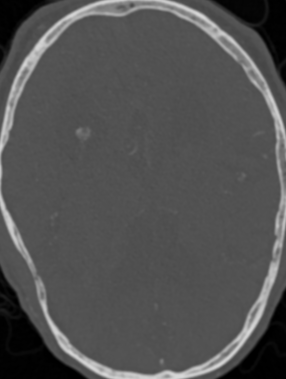

In [10]:
print_bold("[Example 01]")
random.seed(0)
load_and_display_middle_slice(random.choice(info["train"].paths), display_header=True)

print_bold("[Example 02]")
random.seed(1)
load_and_display_middle_slice(random.choice(info["train"].paths), axis=[0,1,2], display_header=True)

### Split train/val/test

In [11]:
from utils import is_medical_volume

In total, there are

In [12]:
IMGs = sum([
    info["train"].paths,
    info["val"].paths if info["val"] is not None else [],
    info["test"].paths if info["test"] is not None else []
], [])

len(IMGs)

90

volumes. First, we discard the outliers:

In [13]:
IMGs = [img_path for img_path in IMGs if os.path.basename(img_path) not in OUTLIERs]

len(IMGs), IMGs[:5]

(90,
 ['/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/imagesTs/topcow_ct_whole_001.nii.gz',
  '/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/imagesTs/topcow_ct_whole_002.nii.gz',
  '/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/imagesTs/topcow_ct_whole_003.nii.gz',
  '/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/imagesTs/topcow_ct_whole_004.nii.gz',
  '/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/imagesTs/topcow_ct_whole_005.nii.gz'])

We have vessel annotations for

In [14]:
HAVE_VESSELs = [
    img_path for img_path in IMGs if is_medical_volume(img_path_to_vessel_path(img_path))
]

if complete_flag:
    HAVE_VESSELs = [
        img_path for img_path in IMGs if is_medical_volume(img_path_to_vessel_path_complete(img_path))
    ]

for selected_pth in HAVE_VESSELs:
    if complete_flag:
        print(selected_pth.split('/')[-1], '--->', img_path_to_vessel_path_complete(selected_pth).split('/')[-1])
    else:
        print(selected_pth.split('/')[-1], '--->', img_path_to_vessel_path(selected_pth).split('/')[-1])
len(HAVE_VESSELs)

topcow_ct_whole_022.nii.gz ---> topcow_ct_whole_022_COMPLETE_new.nii.gz


1

of them. With a chosen ratio of 70-15-15, we select

In [15]:
COUNT_TEST = len(HAVE_VESSELs if VESSELs_REQUIRED else IMGs) * 15 // 100
COUNT_TEST

13

images to be part of the validation/testing set.

In case brain masks are available, we collect them too.

In [19]:
BRAIN_PATHs = [img_path_to_brain_path(img_path) for img_path in IMGs]

for bp in BRAIN_PATHs[:5]:
    print(bp)

/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/brainTs/topcow_ct_whole_001_brain_join_mask.nii.gz
/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/brainTs/topcow_ct_whole_002_brain_join_mask.nii.gz
/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/brainTs/topcow_ct_whole_003_brain_join_mask.nii.gz
/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/brainTs/topcow_ct_whole_004_brain_join_mask.nii.gz
/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/brainTs/topcow_ct_whole_005_brain_join_mask.nii.gz


In [20]:
HAVE_BRAINs = [
    img_path for img_path in IMGs if is_medical_volume(img_path_to_brain_path(img_path))
]

len(HAVE_BRAINs)

90

Finally, we randomly split our dataset. 

In [21]:
random.seed(0)
TEST_IMGs = range(len(IMGs)+1) # Eveerything is a test image
if MOD == 'MR':
    TEST_IMGs = [os.path.join(DATA_PATH, "topcow_mr_whole_{:03d}.nii.gz".format(i)) for i in TEST_IMGs]
else:
    TEST_IMGs = [os.path.join(DATA_PATH, "topcow_ct_whole_{:03d}.nii.gz".format(i)) for i in TEST_IMGs]

random.seed(0)

TEST_IMGs = [test_img for test_img in TEST_IMGs if os.path.exists(test_img)]
TEST_IMGs

['/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/imagesTs/topcow_ct_whole_001.nii.gz',
 '/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/imagesTs/topcow_ct_whole_002.nii.gz',
 '/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/imagesTs/topcow_ct_whole_003.nii.gz',
 '/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/imagesTs/topcow_ct_whole_004.nii.gz',
 '/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/imagesTs/topcow_ct_whole_005.nii.gz',
 '/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/imagesTs/topcow_ct_whole_006.nii.gz',
 '/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/imagesTs/topcow_ct_whole_007.nii.gz',
 '/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/imagesTs/topcow_ct_whole_008.nii.gz',
 '/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/imagesTs/topcow_ct_whole_009.nii.gz',
 '/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/imagesTs/topcow_ct_whole_010.nii.gz',
 '/data/falcetta/NNUNET25/nnUNet_raw/Dataset301_CTCOW23/imag

In [22]:
TRAIN_IMGs = [img for img in IMGs if HAVE_VESSELs.count(img) > 0]
TEST_IMGs = [img for img in TEST_IMGs if img not in TRAIN_IMGs]

In [23]:
VAL_IMGs = random.sample(sorted([img for img in IMGs if img not in TRAIN_IMGs]), COUNT_TEST)
TEST_IMGs = [img for img in TEST_IMGs if img not in VAL_IMGs]

In [24]:
print(f'Patients in training set: {len(TRAIN_IMGs)}')
print(f'Patients in validation set: {len(VAL_IMGs)}')
print(f'Patients in test set: {len(TEST_IMGs)}')

Patients in training set: 1
Patients in validation set: 13
Patients in test set: 76


In [25]:
if JUST_TEST:
    TRAIN_IMGs = []
    VAL_IMGs = []
    TEST_IMGs = IMGs
    print(f"WARNING: You are selecting only the test set (#{len(TEST_IMGs)} Imgs).")
else:
    print("WARNING: You are selecting a subset of the dataset for training and validation.")

In [26]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Extract spacings and shapes

In [27]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [28]:
from utils import extract_info_and_masks, loop_nii, display_info, get_target_spacing

In [29]:
info = {
    "train": extract_info_and_masks(path_rule=PATH_RULE),
    "val": extract_info_and_masks(path_rule=PATH_RULE),
    "test": extract_info_and_masks(path_rule=PATH_RULE),
}

loop_nii(TRAIN_IMGs, info["train"])
loop_nii(VAL_IMGs, info["val"])
loop_nii(TEST_IMGs, info["test"])

In [30]:
if JUST_TEST:
    display_info(info["test"], info["test"])
else:
    display_info(info["train"], info["val"])

,#volumes,#slices,spacing median,spacing range,shape median,shape range
TRAIN,90,19334,[000.43 000.43 000.70],[000.34 000.34 000.30] - [000.63 000.63 000.75],[307.50 379.00 206.00],[208.00 279.00 149.00] - [391.00 481.00 527.00]
VAL,90,19334,[000.43 000.43 000.70],[000.34 000.34 000.30] - [000.63 000.63 000.75],[307.50 379.00 206.00],[208.00 279.00 149.00] - [391.00 481.00 527.00]


In [31]:
if JUST_TEST:
    SPACING = get_target_spacing(
        info["test"].spacings, info["test"].shapesAfterCropping()
    )
else:
    SPACING = get_target_spacing(
        info["train"].spacings + info["val"].spacings,
        info["train"].shapesAfterCropping() + info["val"].shapesAfterCropping()
)

SPACING

array([0.43164062, 0.43164062, 0.70001221])

In [32]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Crop, Metadata, Resize, Empty Slices Removal, Standardization

In [33]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [34]:
import os

from utils import print_bold, preprocessing_loop

In [35]:
print_bold("Training")
preprocessing_loop(
    info["train"],
    os.path.join(OUT_DIR,"numpy", "train"),
    target_spacing=SPACING
)

print_bold("Validation")
preprocessing_loop(
    info["val"],
    os.path.join(OUT_DIR,"numpy", "val"),
    target_spacing=SPACING
)

print_bold("Testing")
preprocessing_loop(
    info["test"],
    os.path.join(OUT_DIR,"numpy", "test"),
    target_spacing=SPACING
)

Training


0it [00:00, ?it/s]


Validation


0it [00:00, ?it/s]


Testing


...

Slices processed: 15122
(323, 462, 206)
Target spacing: [0.43164062 0.43164062 0.70001221]
Current spacing: [0.390625   0.390625   0.70007324]
New shape: [292 418 206]
Resized shape: (292, 418, 206)
PASSED New shape: [512, 512]
New shape: [512 512 206]
Resized shape: (512, 512, 206)


 99%|█████████▉| 89/90 [45:42<00:30, 30.37s/it]

Slices processed: 15304
(320, 376, 212)
Target spacing: [0.43164062 0.43164062 0.70001221]
Current spacing: [0.43164062 0.43164062 0.75      ]
New shape: [320 376 227]
Resized shape: (320, 376, 227)
PASSED New shape: [512, 512]
New shape: [512 512 227]
Resized shape: (512, 512, 227)


100%|██████████| 90/90 [46:17<00:00, 30.86s/it]

Slices processed: 15486


In [36]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Outliers removal and slices extraction

In [37]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [38]:
import os

from utils import print_bold, extraction_loop, display_slice

In [39]:
print_bold("Training")
extraction_loop(
    info["train"],
    os.path.join(OUT_DIR,"slices", "train")
)

print_bold("Validation")
extraction_loop(
    info["val"],
    os.path.join(OUT_DIR,"slices", "val")
)

print_bold("Testing")
extraction_loop(
    info["test"],
    os.path.join(OUT_DIR,"slices", "test")
)

Training


0it [00:00, ?it/s]


Validation


0it [00:00, ?it/s]


Testing


100%|██████████| 90/90 [01:33<00:00,  1.04s/it]


In [40]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Intensity values analysis

In [41]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [42]:
import numpy as np

from utils import intensity_loop, display_intensity
from utils import get_percentile, display_clipped_slice, print_bold

Testing


100%|██████████| 90/90 [01:30<00:00,  1.00s/it]


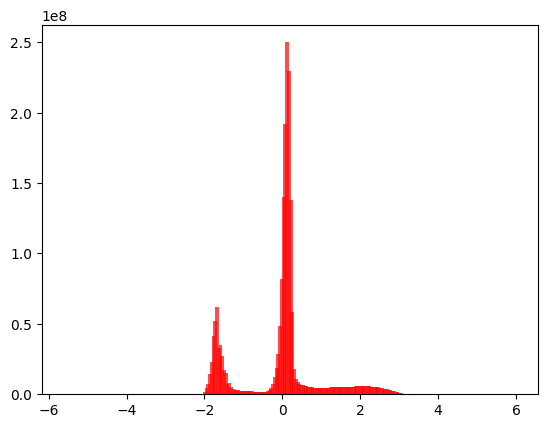

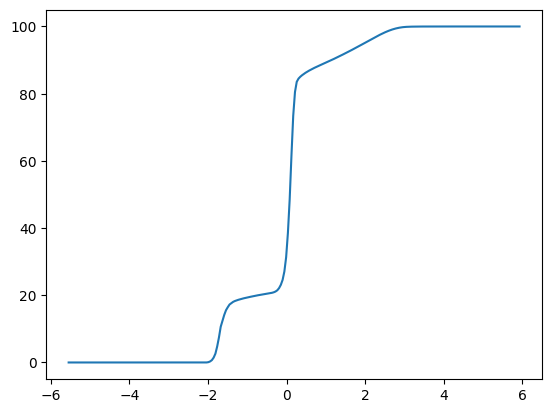

In [43]:
if JUST_TEST:
    print_bold("Testing")
    intensity_loop(
        info["test"],
        min_value=min(info["test"].min_values),
        max_value=max(info["test"].max_values)
    )
    display_intensity(info["test"])
else:
    print_bold("Training")
    intensity_loop(
        info["train"],
        min_value=min(info["train"].min_values + info["val"].min_values),
        max_value=max(info["train"].max_values + info["val"].max_values)
    )
    display_intensity(info["train"])

    print_bold("Validation")
    intensity_loop(
        info["val"],
        min_value=min(info["train"].min_values + info["val"].min_values),
        max_value=max(info["train"].max_values + info["val"].max_values)
    )
    display_intensity(info["val"])

In [44]:
if JUST_TEST:
    MIN_VALUE = get_percentile(
        info["test"].bins,
        info["test"].intensity_count,
        0.1
    )
    MAX_VALUE = get_percentile(
        info["test"].bins,
        info["test"].intensity_count,
        99.9
    )
else:
    MIN_VALUE = get_percentile(
        info["train"].bins,
        info["train"].intensity_count + info["val"].intensity_count,
        0.1
    )
    MAX_VALUE = get_percentile(
        info["train"].bins,
        info["train"].intensity_count + info["val"].intensity_count,
        99.9
)

print(MIN_VALUE, MAX_VALUE)

-1.9024723912037578 3.138764010245188


In [45]:
if JUST_TEST:
    min_values_idx = np.argmin(info["test"].min_values)
    max_values_idx = np.argmax(info["test"].max_values)
else:
    min_values_idx = np.argmin(
        info["train"].min_values + info["val"].min_values
    )
    max_values_idx = np.argmax(
        info["train"].max_values + info["val"].max_values
    )

if JUST_TEST:
    DARK = info["test"].preprocessed_paths[min_values_idx]
    BRIGHT = info["test"].preprocessed_paths[max_values_idx]
else:
    DARK = (info["train"].preprocessed_paths + info["val"].preprocessed_paths)[min_values_idx]
    BRIGHT = (info["train"].preprocessed_paths + info["val"].preprocessed_paths)[max_values_idx]
print(DARK, BRIGHT)

/data/falcetta/TOPCOW_RES/A2V/23/CT/numpy/test/topcow_ct_whole_001.npy /data/falcetta/TOPCOW_RES/A2V/23/CT/numpy/test/topcow_ct_whole_029.npy


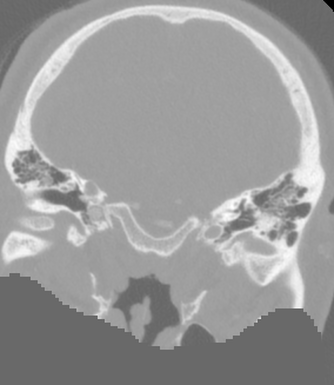

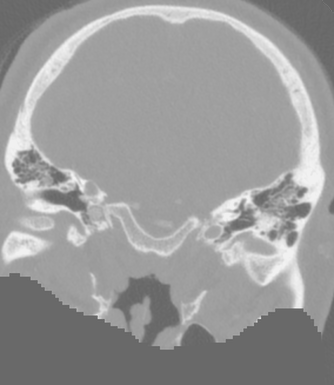

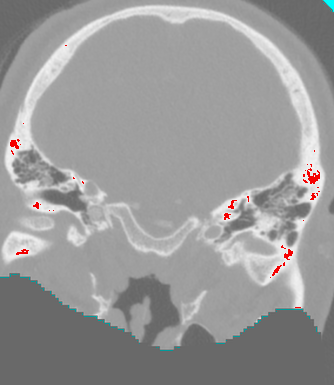

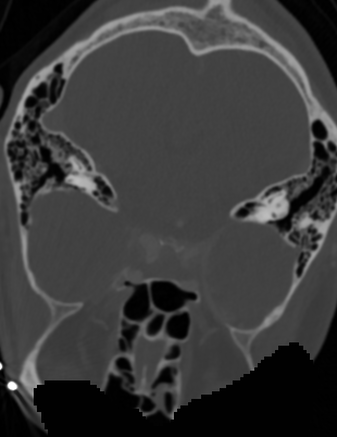

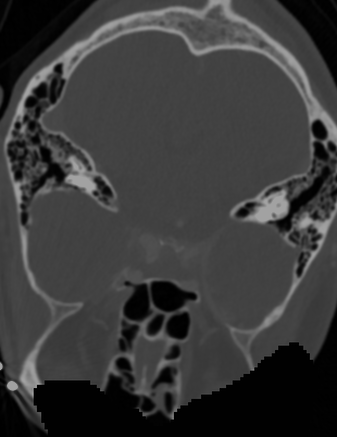

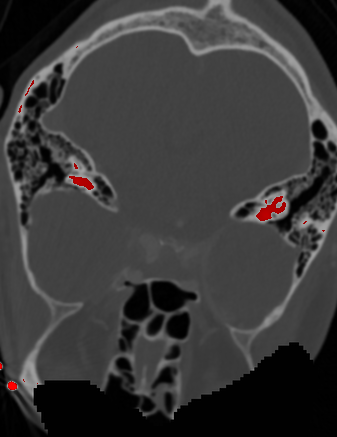

In [46]:
DARK = DARK.replace("numpy/", "slices/").replace(".npy", "_slice{:03d}.npy").format(50)
display_clipped_slice(DARK, MIN_VALUE, MAX_VALUE)


BRIGHT = BRIGHT.replace("numpy/", "slices/").replace(".npy", "_slice{:03d}.npy").format(50)
display_clipped_slice(BRIGHT, MIN_VALUE, MAX_VALUE)


In [47]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Normalization, Padding & Cropping, One-Hot Encoding

In [48]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [49]:
import numpy as np

from utils import display_slice, normalization_loop

In [50]:
print_bold("Training")
normalization_loop(info["train"], f"{OUT_DIR}/preprocess_{DATASET_NAME}/train", MIN_VALUE, MAX_VALUE)#, delete_old=False)#TO DELETE

print_bold("Validation")
normalization_loop(info["val"], f"{OUT_DIR}/preprocess_{DATASET_NAME}/val", MIN_VALUE, MAX_VALUE)#, delete_old=False)#TO DELETE

print_bold("Testing")
normalization_loop(info["test"], f"{OUT_DIR}/preprocess_{DATASET_NAME}/test", MIN_VALUE, MAX_VALUE)#, delete_old=False)#TO DELETE

Training


0it [00:00, ?it/s]


Validation


0it [00:00, ?it/s]


Testing


100%|██████████| 90/90 [03:56<00:00,  2.63s/it]


In [51]:
np.save(f"{OUT_DIR}/preprocess_map_{DATASET_NAME}.npy", {
    "train": sorted(os.listdir(f"{OUT_DIR}/preprocess_{DATASET_NAME}/train")),
    "val": sorted(os.listdir(f"{OUT_DIR}/preprocess_{DATASET_NAME}/val")),
    "test": sorted(os.listdir(f"{OUT_DIR}/preprocess_{DATASET_NAME}/test")),
})

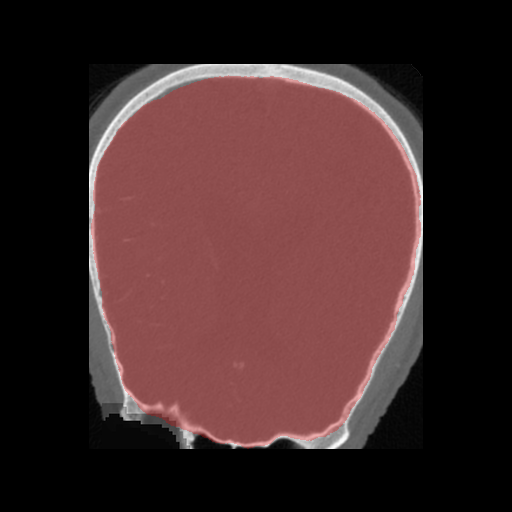

In [52]:
if JUST_TEST:
    if YEAR == '24' and MOD == 'MR':
        img_example = np.load(
            f"{OUT_DIR}/preprocess_{DATASET_NAME}/test/topcow_mr_001_slice130.npy", allow_pickle=True
        ).item()
    elif YEAR == '24' and MOD == 'CT':
        img_example = np.load(
            f"{OUT_DIR}/preprocess_{DATASET_NAME}/test/topcow_ct_001_slice130.npy", allow_pickle=True
        ).item()
    elif YEAR == '23' and MOD == 'MR':
        img_example = np.load(
            f"{OUT_DIR}/preprocess_{DATASET_NAME}/test/topcow_mr_whole_001_slice130.npy", allow_pickle=True
        ).item()
    elif YEAR == '23' and MOD == 'CT':
        img_example = np.load(
            f"{OUT_DIR}/preprocess_{DATASET_NAME}/test/topcow_ct_whole_001_slice130.npy", allow_pickle=True
        ).item()
else:
    if YEAR == '24' and MOD == 'MR':
        img_example = np.load(
            f"{OUT_DIR}/preprocess_{DATASET_NAME}/train/topcow_mr_001_slice130.npy", allow_pickle=True
        ).item()
    elif YEAR == '24' and MOD == 'CT':
        img_example = np.load(
            f"{OUT_DIR}/preprocess_{DATASET_NAME}/train/topcow_ct_001_slice130.npy", allow_pickle=True
        ).item()
    elif YEAR == '23' and MOD == 'MR':
        img_example = np.load(
            f"{OUT_DIR}/preprocess_{DATASET_NAME}/train/topcow_mr_whole_001_slice130.npy", allow_pickle=True
        ).item()
    elif YEAR == '23' and MOD == 'CT':
        img_example = np.load(
            f"{OUT_DIR}/preprocess_{DATASET_NAME}/train/topcow_ct_whole_001_slice130.npy", allow_pickle=True
        ).item()
    
img_example, msk_example = img_example["data"][:,:,0], img_example["mask"]

msk_example = np.argmax(msk_example, axis=-1)

display_slice(img_example, min_val=-1, max_val=1, mask=msk_example/2)